In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Set a random state for reproducibility across all steps
RANDOM_STATE = 42

try:
    # Assuming 'bank.csv' is the dataset based on your previous notebook
    df = pd.read_csv("C:/Users/anusha/OneDrive/Desktop/bank.csv", sep=';')
    print("Data loaded successfully.")
    print(f"Dataset shape: {df.shape}")
    print("\nInitial Target Variable Distribution ('y'):")
    print(df['y'].value_counts(normalize=True))
except FileNotFoundError:
    print("Error: 'bank.csv' not found. Please ensure the file is in the correct directory.")
    exit()

# A. Handle the Target Variable ('y'): Convert 'yes' to 1 and 'no' to 0
df['y'] = df['y'].map({'yes': 1, 'no': 0})

Data loaded successfully.
Dataset shape: (4521, 17)

Initial Target Variable Distribution ('y'):
y
no     0.88476
yes    0.11524
Name: proportion, dtype: float64


In [7]:
# B. One-Hot Encoding for Nominal Categorical Features
categorical_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"Shape after One-Hot Encoding: {df_encoded.shape}")

# C. Separate Features (X) and Target (y)
X = df_encoded.drop('y', axis=1) # Features
y = df_encoded['y']           # Target

# D. Split data into training (80%) and testing (20%) sets
# 'stratify=y' ensures the test set has a similar class distribution to the original data.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Shape after One-Hot Encoding: (4521, 43)

Training set size: 3616 samples
Testing set size: 905 samples


In [9]:
# 3.1 Define the parameter grid to search
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 20]
}

# 3.2 Initialize GridSearchCV
# class_weight='balanced' adjusts weights inversely proportional to class frequencies,
# and scoring='roc_auc' is robust for imbalance.
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5, # 5-fold cross-validation
    verbose=1,
    n_jobs=-1
)

# 3.3 Execute the grid search on the training data
grid_search.fit(X_train, y_train)

# 3.4 Get the best model and parameters
best_dt_model = grid_search.best_estimator_
best_params = grid_search.best_params_
print(f"\nBest Parameters Found: {best_params}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best Parameters Found: {'max_depth': 7, 'min_samples_leaf': 20, 'min_samples_split': 10}


In [11]:
# 4.1 Make predictions and get probabilities
y_pred = best_dt_model.predict(X_test)
# Get probability of the positive class (index 1) for ROC AUC
y_proba = best_dt_model.predict_proba(X_test)[:, 1]

# 4.2 Generate key metrics
print("\n--- Model Evaluation on Test Set ---")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification Report (Focus on 'Yes' class, label 1):")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix (True Labels vs. Predicted Labels):")
print(confusion_matrix(y_test, y_pred))


--- Model Evaluation on Test Set ---
ROC AUC Score: 0.8438

Classification Report (Focus on 'Yes' class, label 1):
              precision    recall  f1-score   support

           0       0.97      0.78      0.86       801
           1       0.32      0.80      0.45       104

    accuracy                           0.78       905
   macro avg       0.64      0.79      0.66       905
weighted avg       0.89      0.78      0.81       905


Confusion Matrix (True Labels vs. Predicted Labels):
[[621 180]
 [ 21  83]]


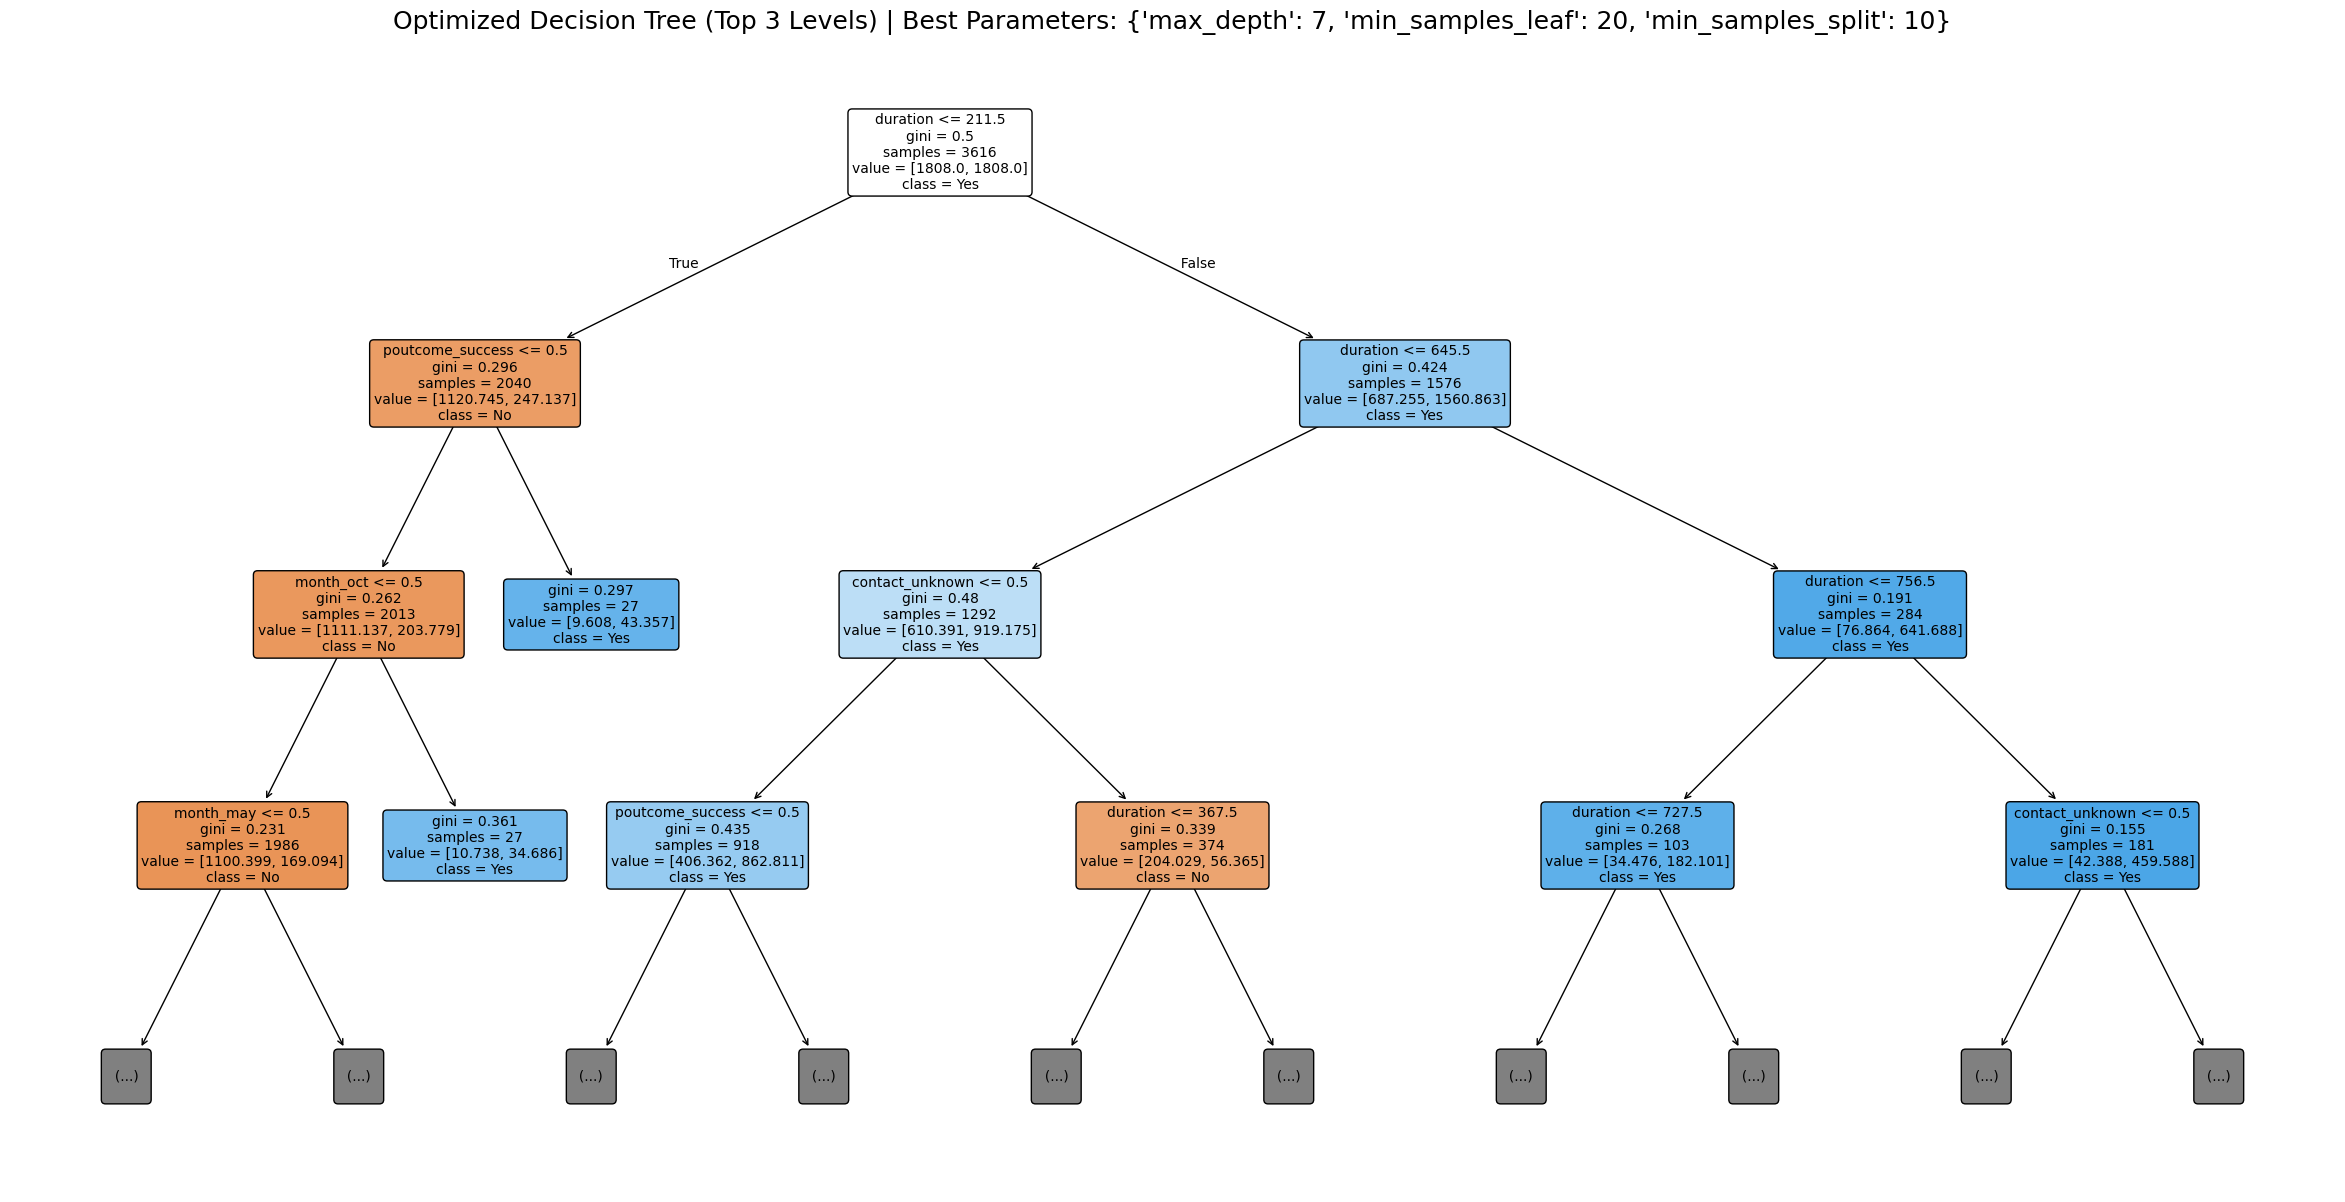


--- Top 10 Feature Importances ---
duration            0.624739
contact_unknown     0.098193
poutcome_success    0.094056
month_oct           0.036501
balance             0.034493
day                 0.020952
month_jul           0.020760
job_blue-collar     0.018962
loan_yes            0.015214
month_may           0.014075
dtype: float64


In [13]:
# 5.1 Visualize the Decision Tree (Truncated for readability)
plt.figure(figsize=(30, 15))
plot_tree(
    best_dt_model,
    feature_names=X.columns.tolist(),
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    max_depth=3, # Show only the top 3 levels for a clean view
    fontsize=10
)
plt.title(f"Optimized Decision Tree (Top 3 Levels) | Best Parameters: {best_params}", fontsize=18)
plt.show()

# 5.2 Optional: View Feature Importance
print("\n--- Top 10 Feature Importances ---")
feature_importances = pd.Series(best_dt_model.feature_importances_, index=X.columns)
print(feature_importances.sort_values(ascending=False).head(10))